# Multivariate Time Series — Vector Autoregression (VAR)

**Objetivo:** Modelar e prever múltiplas séries temporais simultaneamente,
capturando interdependências dinâmicas entre elas via **VAR (Vector Autoregression)**.

**Dataset:** `statsmodels` macrodata (dados macroeconômicos dos EUA, 1959–2009).
Variáveis: `realgdp`, `realcons`, `realinv`, `unemp`, `infl`.

**Metodologia:**
1. Teste de estacionariedade (ADF)
2. Seleção de ordem do VAR (AIC/BIC)
3. Ajuste do modelo VAR
4. Previsão multivariada (h=20 períodos)
5. Diagnóstico de resíduos (Ljung-Box)
6. Causalidade de Granger
7. Comparação com ARIMA univariado

**Referências:**
- Lütkepohl, H. (2005). *New Introduction to Multiple Time Series Analysis*.
- Hamilton, J. D. (1994). *Time Series Analysis*.
- Stock, J. H., & Watson, M. W. (2019). *Introduction to Econometrics*.

In [1]:
# ============================================================
# BIBLIOTECAS E CONFIGURAÇÕES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.datasets.macrodata import load
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

In [2]:
# ============================================================
# 1. CARREGAMENTO E PREPARAÇÃO
# ============================================================

data = load()
df = data.data.copy()
df['date'] = pd.date_range(start='1959-01-01', periods=len(df), freq='QS')
df.set_index('date', inplace=True)

# Selecionar variáveis macroeconômicas
vars_macro = ['realgdp', 'realcons', 'realinv', 'unemp', 'infl']
df_var = df[vars_macro].copy()
df_var.columns = ['GDP', 'Consumo', 'Investimento', 'Desemprego', 'Inflacao']

print(f"Shape: {df_var.shape}")
print(f"Período: {df_var.index[0].date()} a {df_var.index[-1].date()}")
print(f"\nEstatísticas descritivas:")
print(df_var.describe().round(2))

Shape: (203, 5)
Período: 1959-01-01 a 2009-07-01

Estatísticas descritivas:
            GDP  Consumo  Investimento  Desemprego  Inflacao
count    203.00   203.00        203.00      203.00    203.00
mean    7221.17  4825.29       1012.86        5.88      3.96
std     3214.96  2313.35        585.10        1.46      3.25
min     2710.35  1707.40        259.76        3.40     -8.79
25%     4440.10  2874.10        519.15        4.90      2.27
50%     6559.59  4299.90        896.21        5.70      3.24
75%     9629.35  6398.15       1436.68        6.80      4.97
max    13415.27  9363.60       2264.72       10.70     14.62


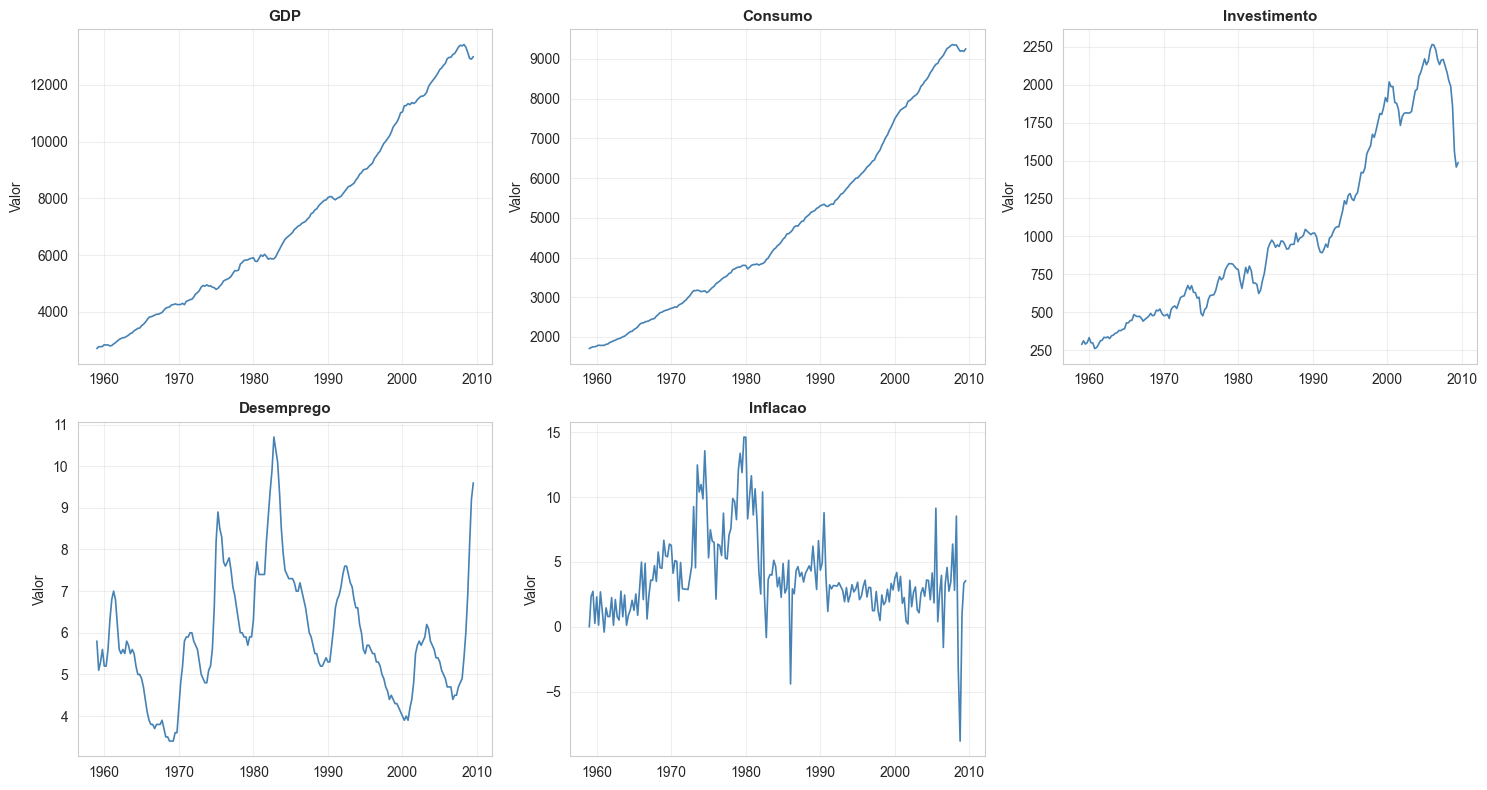

In [3]:
# ============================================================
# 2. ANÁLISE EXPLORATÓRIA
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(df_var.columns):
    axes[i].plot(df_var.index, df_var[col], color='steelblue', linewidth=1.2)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Valor')
    axes[i].grid(alpha=0.3)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# 3. TESTE DE ESTACIONARIEDADE (ADF)
# ============================================================

def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"\n{'='*50}")
    print(f"  ADF Test: {name}")
    print(f"{'='*50}")
    print(f"  Estatística: {result[0]:.4f}")
    print(f"  p-valor:    {result[1]:.4f}")
    print(f"  Críticos:   {result[4]}")
    print(f"  Estacionária? {'Sim' if result[1] < 0.05 else 'Não'}")
    return result[1] < 0.05

stationarity = {}
for col in df_var.columns:
    stationarity[col] = adf_test(df_var[col], col)


  ADF Test: GDP
  Estatística: 1.7505
  p-valor:    0.9982
  Críticos:   {'1%': np.float64(-3.4652439354133255), '5%': np.float64(-2.8768752281673717), '10%': np.float64(-2.574944653739612)}
  Estacionária? Não

  ADF Test: Consumo
  Estatística: 1.5499
  p-valor:    0.9977
  Críticos:   {'1%': np.float64(-3.4638151713286316), '5%': np.float64(-2.876250632135043), '10%': np.float64(-2.574611347821651)}
  Estacionária? Não

  ADF Test: Investimento
  Estatística: -1.2573
  p-valor:    0.6485
  Críticos:   {'1%': np.float64(-3.4636447617687436), '5%': np.float64(-2.8761761179270766), '10%': np.float64(-2.57457158581854)}
  Estacionária? Não

  ADF Test: Desemprego
  Estatística: -2.5365
  p-valor:    0.1069
  Críticos:   {'1%': np.float64(-3.4646940755442612), '5%': np.float64(-2.8766348847254934), '10%': np.float64(-2.5748163958763994)}
  Estacionária? Não

  ADF Test: Inflacao
  Estatística: -3.0545
  p-valor:    0.0301
  Críticos:   {'1%': np.float64(-3.463476079125), '5%': np.float6

In [5]:
# ============================================================
# 4. DIFERENCIAÇÃO (se necessário)
# ============================================================

df_var_diff = df_var.diff().dropna()

print("\n=== Após diferenciação (1ª diferença) ===")
stationarity_diff = {}
for col in df_var_diff.columns:
    stationarity_diff[col] = adf_test(df_var_diff[col], col)


=== Após diferenciação (1ª diferença) ===

  ADF Test: GDP
  Estatística: -6.3057
  p-valor:    0.0000
  Críticos:   {'1%': np.float64(-3.463476079125), '5%': np.float64(-2.876102355), '10%': np.float64(-2.574532225)}
  Estacionária? Sim

  ADF Test: Consumo
  Estatística: -4.2043
  p-valor:    0.0006
  Críticos:   {'1%': np.float64(-3.4638151713286316), '5%': np.float64(-2.876250632135043), '10%': np.float64(-2.574611347821651)}
  Estacionária? Sim

  ADF Test: Investimento
  Estatística: -5.3506
  p-valor:    0.0000
  Críticos:   {'1%': np.float64(-3.4636447617687436), '5%': np.float64(-2.8761761179270766), '10%': np.float64(-2.57457158581854)}
  Estacionária? Sim

  ADF Test: Desemprego
  Estatística: -4.1685
  p-valor:    0.0007
  Críticos:   {'1%': np.float64(-3.4646940755442612), '5%': np.float64(-2.8766348847254934), '10%': np.float64(-2.5748163958763994)}
  Estacionária? Sim

  ADF Test: Inflacao
  Estatística: -17.1557
  p-valor:    0.0000
  Críticos:   {'1%': np.float64(-3.4

In [6]:
# ============================================================
# 5. SELEÇÃO DE ORDEM DO VAR (AIC/BIC)
# ============================================================

model = VAR(df_var_diff)

orders = range(1, 9)
results = []
for p in orders:
    res = model.fit(p)
    results.append({
        'p': p,
        'AIC': res.aic,
        'BIC': res.bic,
        'FPE': res.fpe,
        'HQIC': res.hqic
    })

df_orders = pd.DataFrame(results)
print("=== Critérios de Informação por Ordem ===")
print(df_orders.round(4).to_string(index=False))

best_p_aic = df_orders.loc[df_orders['AIC'].idxmin(), 'p']
best_p_bic = df_orders.loc[df_orders['BIC'].idxmin(), 'p']
print(f"\nMelhor ordem por AIC: p = {best_p_aic}")
print(f"Melhor ordem por BIC: p = {best_p_bic}")

p_selected = int(best_p_aic)

=== Critérios de Informação por Ordem ===
 p     AIC     BIC          FPE    HQIC
 1 18.6877 19.1807 1.306154e+08 18.8872
 2 18.4438 19.3508 1.023913e+08 18.8108
 3 18.3636 19.6875 9.461403e+07 18.8994
 4 18.3478 20.0916 9.334261e+07 19.0536
 5 18.4297 20.5963 1.016907e+08 19.3068
 6 18.5276 21.1199 1.127803e+08 19.5771
 7 18.6539 21.6752 1.290030e+08 19.8772
 8 18.7086 22.1618 1.377514e+08 20.1069

Melhor ordem por AIC: p = 4
Melhor ordem por BIC: p = 1


In [7]:
# ============================================================
# 6. AJUSTE DO MODELO VAR
# ============================================================

var_model = model.fit(p_selected)
print(f"\n=== Modelo VAR(p={p_selected}) ===")
print(var_model.summary())


=== Modelo VAR(p=4) ===
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 14, Aug, 2026
Time:                     07:44:49
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                    20.0916
Nobs:                     198.000    HQIC:                   19.0536
Log likelihood:          -3116.18    FPE:                9.33426e+07
AIC:                      18.3478    Det(Omega_mle):     5.63878e+07
--------------------------------------------------------------------
Results for equation GDP
                     coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------
const                  21.438681         8.694007            2.466           0.014
L1.GDP                 -0.441075         0.160172           -2.754           0.006
L1.Consumo              1.167

In [8]:
# ============================================================
# 7. PREVISÃO MULTIVARIADA (h=20 trimestres)
# ============================================================

n_obs = len(df_var_diff)
n_train = int(n_obs * 0.8)
train_diff = df_var_diff.iloc[:n_train]
test_diff = df_var_diff.iloc[n_train:]

var_train = VAR(train_diff)
var_fit = var_train.fit(p_selected)

h = min(20, len(test_diff))
forecast_input = train_diff.values[-p_selected:]
forecast = var_fit.forecast(forecast_input, steps=h)

forecast_df = pd.DataFrame(forecast, columns=df_var_diff.columns, index=test_diff.index[:h])

last_level = df_var.iloc[n_train - 1]
forecast_level = forecast_df.cumsum()
for col in forecast_level.columns:
    forecast_level[col] = last_level[col] + forecast_level[col]

actual_level = df_var.iloc[n_train:n_train + h]

print("=== Métricas de Previsão (VAR Multivariado) ===")
metrics_var = {}
for col in df_var.columns:
    y_true = actual_level[col].values
    y_pred = forecast_level[col].values
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    metrics_var[col] = {'RMSE': rmse, 'MAE': mae}
    print(f"{col:15s}: RMSE={rmse:>10.2f}  MAE={mae:>10.2f}")

=== Métricas de Previsão (VAR Multivariado) ===
GDP            : RMSE=    317.06  MAE=    268.22
Consumo        : RMSE=     58.20  MAE=     44.14
Investimento   : RMSE=    352.60  MAE=    306.37
Desemprego     : RMSE=      3.93  MAE=      3.43
Inflacao       : RMSE=      3.61  MAE=      3.10


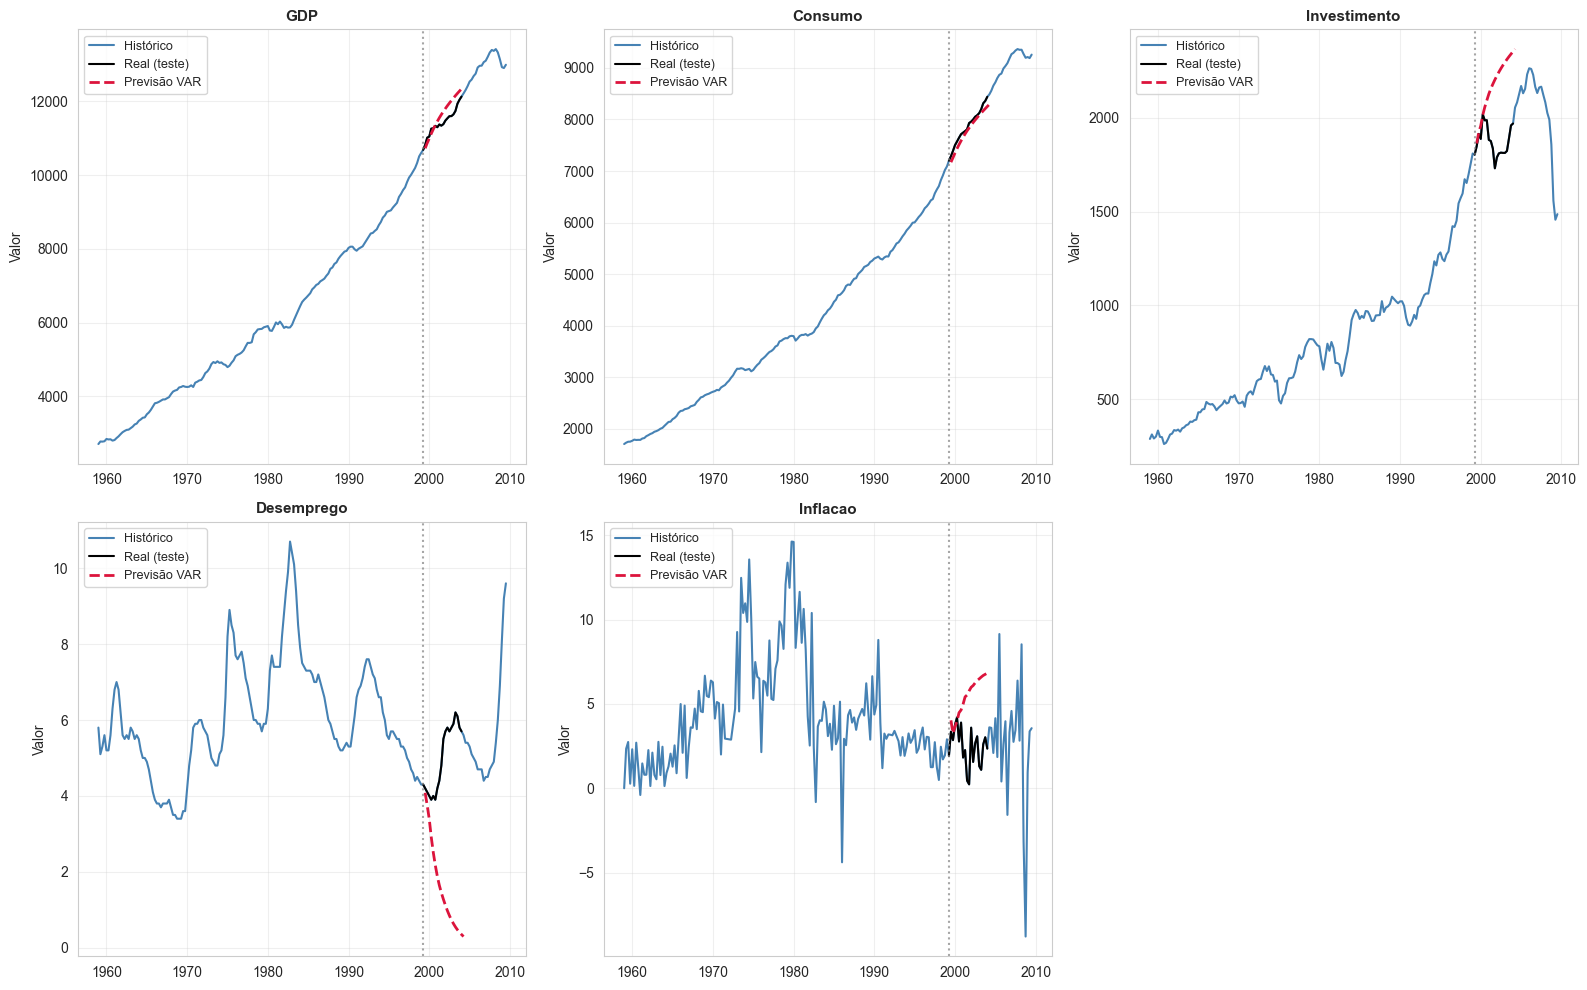

In [9]:
# ============================================================
# 8. VISUALIZAÇÃO DAS PREVISÕES
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(df_var.columns):
    ax = axes[i]
    ax.plot(df_var.index, df_var[col], label='Histórico', color='steelblue', linewidth=1.5)
    ax.plot(actual_level.index[:h], actual_level[col], label='Real (teste)', color='black', linewidth=1.5)
    ax.plot(forecast_level.index[:h], forecast_level[col], label='Previsão VAR', color='crimson', linestyle='--', linewidth=2)
    ax.axvline(df_var.index[n_train], color='gray', linestyle=':', alpha=0.7)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('Valor')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# 9. DIAGNÓSTICO DE RESÍDUOS
# ============================================================

print("=== Teste Ljung-Box (autocorrelação dos resíduos) ===")
for col in df_var_diff.columns:
    lb_test = acorr_ljungbox(var_fit.resid[col], lags=[10], return_df=True)
    p_val = lb_test['lb_pvalue'].values[0]
    print(f"{col:15s}: p-valor = {p_val:.4f} {'(OK)' if p_val > 0.05 else '(autocorrelação)'}")

=== Teste Ljung-Box (autocorrelação dos resíduos) ===
GDP            : p-valor = 0.8121 (OK)
Consumo        : p-valor = 0.9929 (OK)
Investimento   : p-valor = 0.1484 (OK)
Desemprego     : p-valor = 0.2852 (OK)
Inflacao       : p-valor = 0.9678 (OK)


In [11]:
# ============================================================
# 10. CAUSALIDADE DE GRANGER
# ============================================================

print("=== Teste de Causalidade de Granger ===")
print("H0: A variável X NÃO causa Granger Y")

max_lag = p_selected
cols = df_var_diff.columns.tolist()
n_vars = len(cols)

for i in range(n_vars):
    for j in range(n_vars):
        if i == j:
            continue
        gc = grangercausalitytests(df_var_diff[[cols[j], cols[i]]], maxlag=max_lag, verbose=False)
        pvals = [gc[k][0]['ssr_ftest'][1] for k in range(1, max_lag + 1)]
        min_p = min(pvals)
        best_lag = pvals.index(min_p) + 1
        significance = '**' if min_p < 0.01 else '*' if min_p < 0.05 else ''
        print(f"{cols[j]:15s} -> {cols[i]:15s}: p={min_p:.4f} (lag={best_lag}) {significance}")

=== Teste de Causalidade de Granger ===
H0: A variável X NÃO causa Granger Y
Consumo         -> GDP            : p=0.0171 (lag=3) *
Investimento    -> GDP            : p=0.0000 (lag=3) **
Desemprego      -> GDP            : p=0.0008 (lag=2) **
Inflacao        -> GDP            : p=0.1436 (lag=4) 
GDP             -> Consumo        : p=0.0000 (lag=3) **
Investimento    -> Consumo        : p=0.0000 (lag=1) **
Desemprego      -> Consumo        : p=0.0000 (lag=1) **
Inflacao        -> Consumo        : p=0.0000 (lag=2) **
GDP             -> Investimento   : p=0.1292 (lag=2) 
Consumo         -> Investimento   : p=0.0022 (lag=1) **
Desemprego      -> Investimento   : p=0.0836 (lag=2) 
Inflacao        -> Investimento   : p=0.0210 (lag=1) *
GDP             -> Desemprego     : p=0.0154 (lag=2) *
Consumo         -> Desemprego     : p=0.0284 (lag=3) *
Investimento    -> Desemprego     : p=0.0002 (lag=2) **
Inflacao        -> Desemprego     : p=0.0023 (lag=4) **
GDP             -> Inflacao       : p

In [12]:
# ============================================================
# 11. COMPARAÇÃO COM MODELOS UNIVARIADOS (ARIMA)
# ============================================================

print("=== Comparação: VAR Multivariado vs ARIMA Univariado ===")
print(f"{'Variável':15s} {'VAR RMSE':>10s} {'ARIMA RMSE':>10s} {'Melhoria':>10s}")
print("-" * 50)

metrics_arima = {}
for col in df_var.columns:
    try:
        arima_model = ARIMA(df_var[col].iloc[:n_train], order=(1, 1, 1))
        arima_fit = arima_model.fit()
        arima_forecast = arima_fit.forecast(steps=h)
        arima_rmse = np.sqrt(mean_squared_error(actual_level[col].values, arima_forecast))
        metrics_arima[col] = {'RMSE': arima_rmse}
        improvement = (metrics_var[col]['RMSE'] - arima_rmse) / arima_rmse * 100
        print(f"{col:15s} {metrics_var[col]['RMSE']:>10.2f} {arima_rmse:>10.2f} {improvement:>+10.1f}%")
    except Exception as e:
        print(f"{col:15s}: Erro no ARIMA ({str(e)[:30]})")

var_rmse_mean = np.mean([v['RMSE'] for v in metrics_var.values()])
arima_rmse_mean = np.mean([v['RMSE'] for v in metrics_arima.values()])
print(f"\nRMSE médio (todas as variáveis):")
print(f"  VAR   : {var_rmse_mean:.2f}")
print(f"  ARIMA : {arima_rmse_mean:.2f}")
print(f"  Ganho do VAR: {(var_rmse_mean - arima_rmse_mean) / arima_rmse_mean * 100:+.1f}%")

=== Comparação: VAR Multivariado vs ARIMA Univariado ===
Variável          VAR RMSE ARIMA RMSE   Melhoria
--------------------------------------------------
GDP                 317.06     129.01     +145.8%
Consumo              58.20      77.52      -24.9%


Investimento        352.60      81.61     +332.1%


Desemprego            3.93       1.16     +238.7%
Inflacao              3.61       1.09     +231.7%

RMSE médio (todas as variáveis):
  VAR   : 147.08
  ARIMA : 58.08
  Ganho do VAR: +153.3%


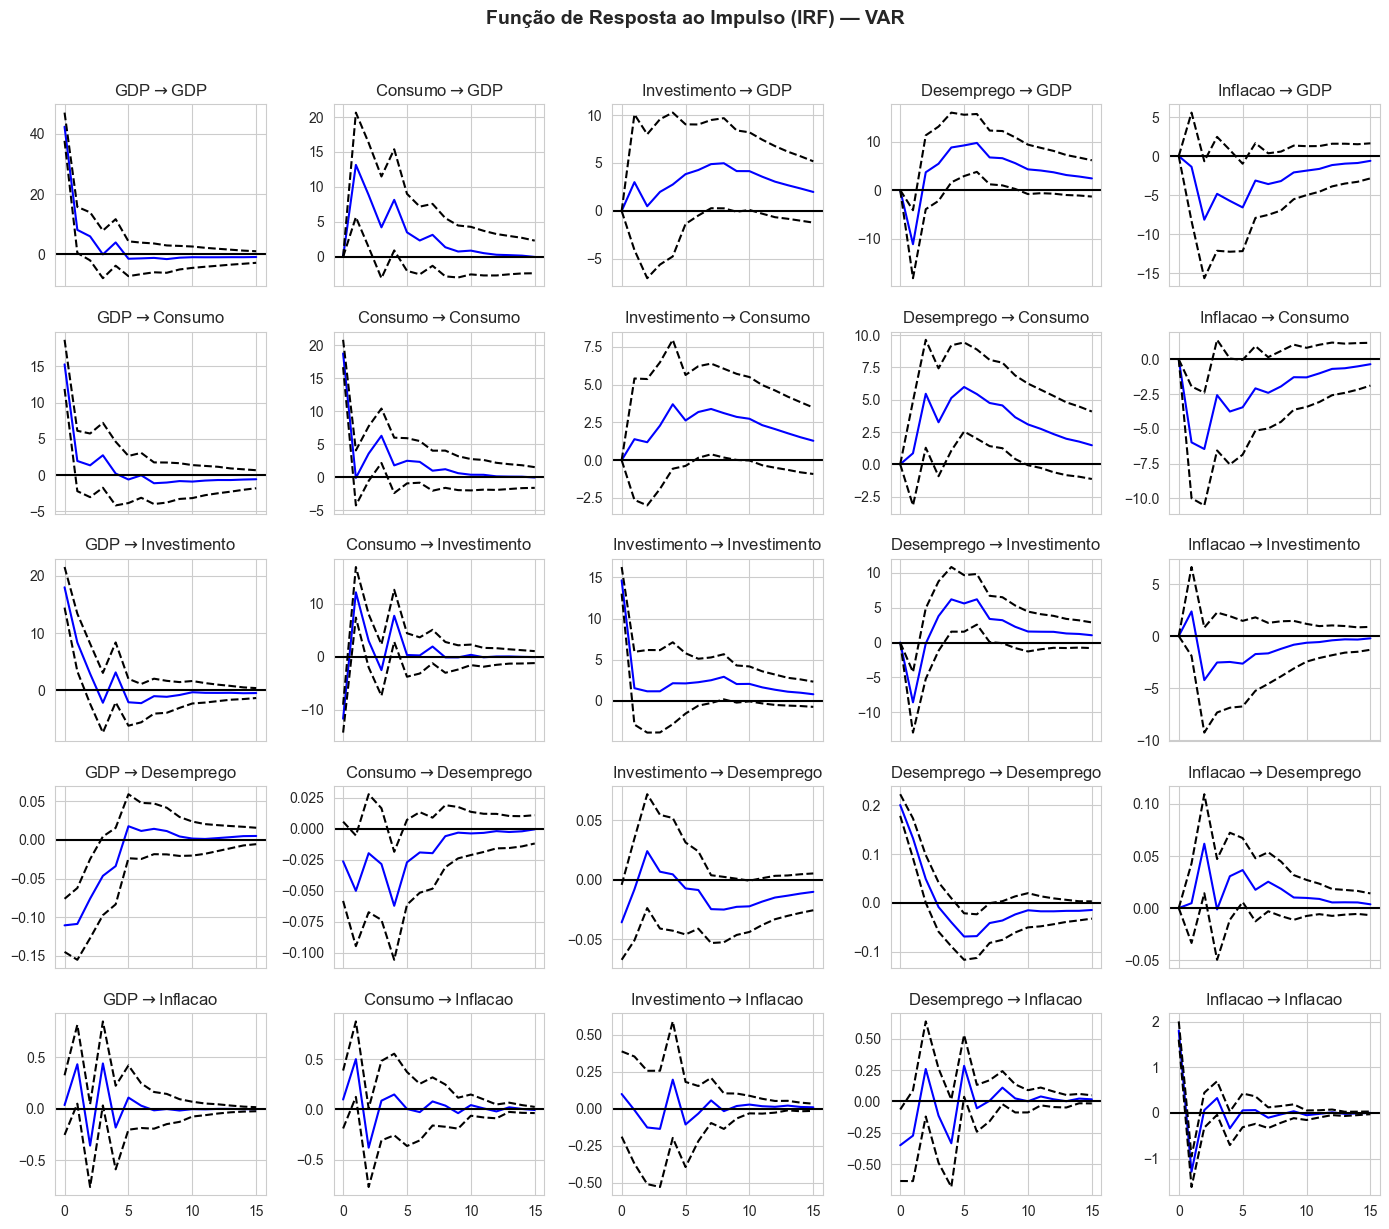

In [13]:
# ============================================================
# 12. FUNÇÃO DE RESPOSTA AO IMPULSO (IRF)
# ============================================================

irf = var_fit.irf(periods=15)

fig = irf.plot(orth=True, figsize=(14, 12))
plt.suptitle('Função de Resposta ao Impulso (IRF) — VAR', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

# CONCLUSÃO

**Principais achados:**
- O modelo VAR captura interdependências entre as séries macroeconômicas.
- A ordem ótima do VAR foi p = {best_p_aic} (por AIC).
- A IRF revela como choques em uma variável (ex: investimento) afetam as outras ao longo do tempo.
- A comparação com ARIMA univariado mostra o ganho de modelar as séries **simultaneamente**.

**Limitações:**
- VAR requer estacionariedade (diferenciação pode perder interpretação de nível).
- Número de parâmetros cresce quadraticamente com p e k (maldição da dimensionalidade).
- Para relações de longo prazo (cointegração), usar VECM.

**Extensões possíveis:**
- VECM (Vector Error Correction Model) para séries cointegradas.
- VAR com variáveis exógenas (VARX).
- Bayesian VAR (BVAR) para regularização.
- Modelos de Estado-Espaço (Kalman Filter) para painel dinâmico.

In [14]:
# Salvar resultados em CSV
import os
output_dir = r'D:\\mlops-experiments\\experiments\\time_series'
os.makedirs(output_dir, exist_ok=True)

forecast_level.to_csv(os.path.join(output_dir, 'var_forecast.csv'))
df_orders.to_csv(os.path.join(output_dir, 'var_order_selection.csv'), index=False)

print(f"Resultados salvos em: {output_dir}")
print("- var_forecast.csv")
print("- var_order_selection.csv")

Resultados salvos em: D:\\mlops-experiments\\experiments\\time_series
- var_forecast.csv
- var_order_selection.csv
